# **NLP Pipeline: AI Assistant for Open-Source Intelligence**
**Project Objective**: International organizations, such as the IAEA, often face the challenge of processing vast amounts of open-source information—particularly international news—to monitor global activities like nuclear trade and safeguards. Manual review of thousands of daily articles is highly time-consuming and difficult to scale.

**The Solution**:To address this challenge, this project uses the nuclear safeguards domain as a practical case study. It demonstrates a Proof of Concept for an "AI Assistant" designed to automate the ingestion of international press, extract key geopolitical entities (NER), translate text into semantic embeddings using Deep Learning, and classify each article's relevance to nuclear safety.

---
**Data Security Note**: This project is an independent prototype developed strictly for demonstration purposes. It relies entirely on public, open-source news datasets and open-weight models. No actual, proprietary, or confidential data from the IAEA was accessed or used in this pipeline.

**[Dataset: all-the-news-2-1.csv](https://www.kaggle.com/datasets/davidmckinley/all-the-news-dataset/data?select=all-the-news-2-1.csv$0)**

## **1. Data Ingestion & Weak Supervision**
The first step in our pipeline is to load the raw news dataset. Since the dataset is unlabelled, we apply a Weak Supervision approach. By defining domain-specific keywords relevant to the IAEA (e.g., nuclear, uranium, inspectors), we automatically generate initial labels to train our downstream models.

In [ ]:
# ==========================================
# 0. LIBRARIES AND IMPORTS
# ==========================================

!pip install transformers pandas torch scikit-learn

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline, AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [102]:
# ==========================================
# 1. DATA LOADING AND WEAK SUPERVISION
# ==========================================

# load the data
df = pd.read_csv('/content/drive/MyDrive/all-the-news-2-1.csv', nrows=1000)
print('Available columns in dataset:\n', df.columns)

# automatic labeling (Weak Supervision) based on keywords
key_words = 'nuclear|uranium|atomic|weapon|IAEA|plutonium|reactor|inspectors'
df['label'] = df['article'].str.contains(key_words, case=False, na=False).astype(int)
print(f"\n{df['label'].sum()} out of {len(df)} loaded articles was automatically labeled as relevant.")

# selecting 300 characters from the first article
sample_text = df['article'].iloc[0]
print(f"\nSample text for analysis (first 300 characters):\n {sample_text[:300]}...")

Available columns in dataset:
 Index(['Unnamed: 0.1', 'Unnamed: 0', 'date', 'year', 'month', 'day', 'author',
       'title', 'article', 'url', 'section', 'publication'],
      dtype='object')

67 out of 1000 loaded articles was automatically labeled as relevant.

Sample text for analysis (first 300 characters):
 This post is part of Polyarchy, an independent blog produced by the political reform program at New America, a Washington think tank devoted to developing new ideas and new voices. Imagine you are an otherwise healthy 30-something who starts feeling weird. You are sometimes short of breath. You get ...


## 2. Named Entity Recognition (NER)
To quickly extract critical information from vast amounts of text, we utilize a pre-trained BERT model from Hugging Face. This NLP component automatically identifies and classifies key entities such as geopolitical locations, organizations, and individuals within the news articles.

In [92]:
# ==========================================
# 2. NAMED ENTITY RECOGNITION (NER)
# ==========================================

# initializing NER pipeline (from Hugging Face)
ner_analysis = pipeline('ner', model='dslim/bert-base-NER', aggregation_strategy='simple')

# running analysis on sample text
results = ner_analysis(sample_text)

# translating results into a dataframe
ner_table = pd.DataFrame(results)

# printing found entities
print("\nFound entities in the sample article:")
if not ner_table.empty:
    print(ner_table[['entity_group', 'word', 'score']].head(20))
else:
    print("No entities found.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Found entities in the sample article:
   entity_group                word     score
0           ORG           Polyarchy  0.968776
1           LOC         New America  0.586793
2           LOC          Washington  0.999364
3           PER         Amanda Taub  0.993953
4           ORG      New York Times  0.987884
5           PER  Roberto Stefan Foa  0.989712
6           PER                  Ya  0.998743
7           PER               ##sch  0.977031
8           PER           ##a Mounk  0.942873
9           PER                Erik  0.958139
10          ORG            New York  0.741669
11          ORG               Times  0.759269
12          PER                Jeff  0.993538
13          PER                 Guo  0.500008
14          ORG             Journal  0.915994
15          ORG           Democracy  0.849272


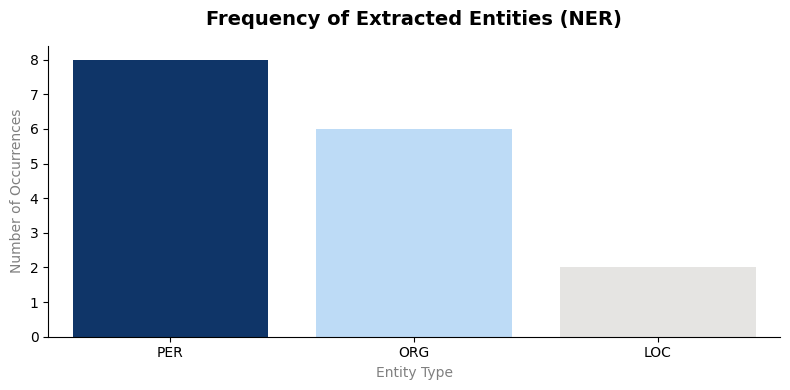

In [110]:
# ==========================================
# 2.5 VISUALIZATION OF FOUND ENTITIES
# ==========================================
if not ner_table.empty:
    plt.figure(figsize=(8, 4))
    mycolors = ['#B4DCFF', '#E5E4E2', '#003377']
    sns.countplot(data=ner_table, x='entity_group', hue='entity_group', palette=mycolors, order=ner_table['entity_group'].value_counts().index, legend=False)

    plt.title('Frequency of Extracted Entities (NER)', pad=15, fontsize=14, fontweight='bold')
    plt.xlabel('Entity Type', fontsize=10, color='grey')
    plt.ylabel('Number of Occurrences', fontsize=10, color='grey')

    sns.despine()

    plt.tight_layout()
    plt.show()
else:
    print("Graph could not be generated because no entities were found in the sample text.")

## 3. Text Embeddings via PyTorch
Computers cannot process raw text directly. In this step, we use a Sentence-Transformer model to map each article into a high-dimensional vector space. These numerical representations (embeddings) capture the semantic meaning and context of the texts.

In [94]:
# ==========================================
# 3. TEXT EMBEDDINGS (PYTORCH)
# ==========================================

# load model for Text Embedding
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
embedding_model = AutoModel.from_pretrained(model_name)

# loading all articles
all_articles = df['article'].tolist()

# function that translates text into numbers (vector) using PyTorch
def get_embedding(text):
    inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt")    # preparing text for model (tokenization)
    with torch.no_grad():                                                                           # computing mathematical values without model training (torch.no_grad)
        outputs = embedding_model(**inputs)
        vector = outputs.last_hidden_state.mean(dim=1)                                              # mean pooling to create one vector for the whole text
    return vector

# tranforming articles into vectors and concatenating into one PyTorch matrix
article_vectors = [get_embedding(str(article)) for article in all_articles]
vector_matrix = torch.cat(article_vectors, dim=0)

print(f"Matrix is ready. Matrix dimension: {vector_matrix.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Matrix is ready. Matrix dimension: torch.Size([1000, 384])


## 4. Semantic Similarity Search
Using the mathematical representations generated in the previous step, we can calculate the cosine similarity between articles. This technique allows analysts to input a specific document and instantly retrieve the most semantically related news items from the database.

In [95]:
# ==========================================
# 4. SIMILARITY SEARCH
# ==========================================

# calculating cosine similarity across all articles
normalized_matrix = torch.nn.functional.normalize(vector_matrix, p=2, dim=1)
similarity_matrix = torch.mm(normalized_matrix, normalized_matrix.t())

# transforming into a dataframe (showing only the first 5x5 for readability)
similarity_df = pd.DataFrame(similarity_matrix[:5, :5].numpy(),
                             columns=[f"Article {i}" for i in range(5)],
                             index=[f"Article {i}" for i in range(5)])

print("\nSimilarity Table Across the Articles - First 5 Articles (1.0 = absolute similarity):\n")
print(similarity_df.round(3))


Similarity Table Across the Articles - First 5 Articles (1.0 = absolute similarity):

           Article 0  Article 1  Article 2  Article 3  Article 4
Article 0      1.000      0.034      0.074      0.219     -0.039
Article 1      0.034      1.000      0.025      0.057      0.016
Article 2      0.074      0.025      1.000      0.157      0.112
Article 3      0.219      0.057      0.157      1.000      0.249
Article 4     -0.039      0.016      0.112      0.249      1.000


## 5. Supervised Learning Classification
We now combine our automatically generated labels with the text embeddings to train a Logistic Regression classifier. The model learns the underlying patterns in the semantic vectors, enabling it to classify future, unseen articles as either relevant or irrelevant to the IAEA's mission.

In [96]:
# ==========================================
# 5. SUPERVISED LEARNING (CLASSIFICATION)
# ==========================================

# preparing features (X) and labels (y) - transforming PyTorch tensor to Numpy array
X = vector_matrix.numpy()
y = df['label'].values

# dividing data into train (80 %) and test (20 %) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model Training
classifier = LogisticRegression(class_weight='balanced') # class_weight='balanced' handles dataset imbalance (if relevant articles are rare)
classifier.fit(X_train, y_train)

# measuring the accuracy of the model on test data
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nThe model has been successfully trained! Accuracy on test data: {accuracy * 100:.1f} %")


The model has been successfully trained! Accuracy on test data: 84.5 %


## 6. Model Evaluation (Confusion Matrix)
To visualize the performance of our classification model on the test data, we generate a Confusion Matrix. This helps us understand not just the overall accuracy, but also the distribution of false positives and false negatives.

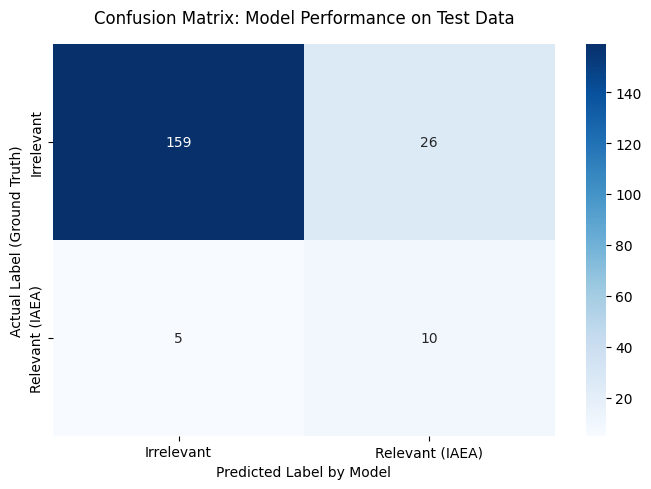

In [105]:
# ==========================================
# 6. VISUALIZATION - (CONFUSION MATRIX)
# ==========================================
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Irrelevant', 'Relevant (IAEA)'],
            yticklabels=['Irrelevant', 'Relevant (IAEA)'])
plt.title('Confusion Matrix: Model Performance on Test Data', pad=15)
plt.ylabel('Actual Label (Ground Truth)')
plt.xlabel('Predicted Label by Model')
plt.tight_layout()

plt.show()

## 7. Inference: Testing on Unseen Data
Finally, we simulate a real-world scenario. We input a brand-new, unseen sentence into the pipeline. The script converts it into an embedding and uses the trained classifier to predict its relevance in real-time, outputting the model's confidence score.

In [98]:
# ==========================================
# 7. INFERENCE (TESTING A NEW ARTICLE)
# ==========================================

# simulating the arrival of a NEW article
new_article = "International inspectors arrived in Vienna to discuss nuclear safety and uranium enrichment facilities."
print(f"\nAnalysis of the new article: '{new_article}'")

# transforming the new article into a vector
new_vector = get_embedding(new_article).numpy()

# prediction
prediction = classifier.predict(new_vector)
probability = classifier.predict_proba(new_vector)

print(f"Resulting model prediction: {'RELEVANT FOR IAEA (1)' if prediction[0] == 1 else 'IRRELEVANT (0)'}")
print(f"Model confidence (probability of relevance): {probability[0][1] * 100:.2f} %")


Analysis of the new article: 'International inspectors arrived in Vienna to discuss nuclear safety and uranium enrichment facilities.'
Resulting model prediction: RELEVANT FOR IAEA (1)
Model confidence (probability of relevance): 99.90 %


## 8. AI Assistant in Action: Filtering the News
To conclude the pipeline, we simulate a daily operational environment. The trained classification model scans the entire ingested news database and predicts the relevance of each article. It then filters the dataset to present only the highly relevant intelligence, effectively reducing information overload for the analysts.

In [101]:
# ========================================================
# 8. AI ASSISTANT IN ACTION: FILTERING THE RELEVANT NEWS
# ========================================================
print("\n--- AI ASSISTANT BRIEFING ---")
print("Scanning the news database for relevant intelligence...\n")

# model classifing all articles
all_predictions = classifier.predict(vector_matrix.numpy())
df['ai_prediction'] = all_predictions

# filtering RELEVANT articles
relevant_articles = df[df['ai_prediction'] == 1]

print(f"Scan complete. Found {len(relevant_articles)} highly relevant articles for IAEA analysts.\n")

# showing first 5 RELEVANT articles
print("Top 5 Relevant Articles for Review:")
print("-" * 40)

for index, row in relevant_articles.head(5).iterrows():
    text_snippet = str(row['article'])[:200].replace('\n', ' ')
    print(f"[ARTICLE ID: {index}]")
    print(f"TEXT: {text_snippet}...\n")


--- AI ASSISTANT BRIEFING ---
Scanning the news database for relevant intelligence...

Scan complete. Found 146 highly relevant articles for IAEA analysts.

Top 5 Relevant Articles for Review:
----------------------------------------
[ARTICLE ID: 3]
TEXT: PARIS (Reuters) - Former French president Nicolas Sarkozy published a new memoir on Thursday but was quick to dismiss speculation he might return to politics to rescue his old center-right party, whic...

[ARTICLE ID: 9]
TEXT: China is dismissing unfavorable media reports as fake news because that’s what Trump does  China is dismissing unfavorable media reports as fake news because that’s what Trump does  In his short polit...

[ARTICLE ID: 25]
TEXT: A six-hour riot that started with a fire and devolved into a rampage through a youth "super jail" in British Columbia this week has confirmed long-held fears over what would happen when the province c...

[ARTICLE ID: 30]
TEXT: PARIS (Reuters) - Libyan eastern commander Khalifa Haftar ha

## 9. Conclusion & Next Steps
This prototype successfully demonstrates a functional, end-to-end Machine Learning pipeline for filtering safeguards-relevant intelligence. By utilizing a sample of 1,000 articles, the model achieved a highly effective balance between rapid execution (processing in under 5 minutes) and robust predictive power. Notably, during live inference, it correctly identified a simulated high-priority report with over 99.90% confidence.

**Future Improvements & Next Steps:**

*   **Scaling Up**: Transitioning the pipeline from a local environment to process the complete dataset of 140,000+ articles using distributed computing.
*   **Advanced Labeling**: Upgrading the keyword-based weak supervision. Implementing a Zero-Shot LLM classifier would create higher-quality ground-truth labels for the supervised model.
*   **Threshold Tuning & Optimization**: Fine-tuning the classification threshold to further minimize False Negatives, which is critical in the nuclear safeguards domain to ensure no vital intelligence is missed.